## **CIFAR-10 Neural Network Evaluation Notebook**

This Jupyter notebook is designed to help verify and understand both the **data pipeline** and the **model behavior** used for the CIFAR-10 classification task. It focuses on two key components:

### **1. Evaluating the `CifarDataModule`**

* The raw CIFAR-10 images are **unnormalized** to restore their original appearance.
* images from a random picked batche are visualized to confirm that:
  * data loading works correctly,
  * normalization and augmentation steps are applied as expected,
  * class labels match the image content.
* This step helps ensure the dataset is prepared properly before feeding it into the neural network.

### **2. Reviewing Model Performance**

* The trained neural network is used to generate predictions on the **training**, **validation**, and **test** datasets.
* For each dataset:
  * images are shown together with their **predicted labels** and compared with their **true labels**,
  * incorrect predictions are highlighted to better understand failure patterns.
* These visualizations supplement numerical evaluation metrics and provide an intuitive understanding of how the model behaves on real samples.

Together, these steps give a clear overview of both the **data quality** and the **model’s predictive performance**, allowing deeper insights into its strengths, limitations, and potential areas for improvement.



In [1]:
from CifarDataModule import CifarDataModule
from CifarNNMdl import CifarNNML

from torch.utils.data import DataLoader
import lightning as L

import matplotlib.pyplot as plt
import torch
import numpy as np
import random

Seed set to 42


In [2]:
# Cifar-10 class names
classes = ['plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

### Evaluating the CifarDataModule

CPU times: user 214 μs, sys: 24 μs, total: 238 μs
Wall time: 240 μs
Files already downloaded and verified
Files already downloaded and verified
CPU times: user 47.9 s, sys: 5.93 s, total: 53.8 s
Wall time: 54 s
CPU times: user 167 μs, sys: 177 μs, total: 344 μs
Wall time: 347 μs


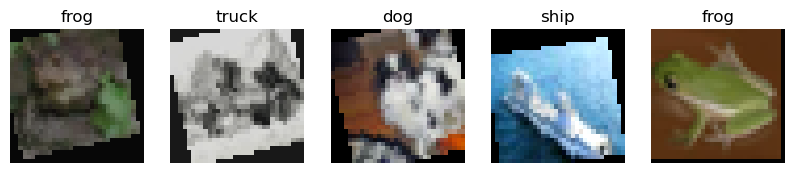

In [3]:
# instance DataModule
%time cifar_data = CifarDataModule()
# set datasets
%time cifar_data.setup()

# get train_dataloader
%time train_loader = cifar_data.train_dataloader()

# get a random batch
images, labels = next(iter(train_loader))  

# pick 5 random indices from the batch
indices = random.sample(range(images.size(0)), 5)

# plot the image with label
plt.figure(figsize=(10, 5))
for i, idx in enumerate(indices):
    img = images[idx].permute(1, 2, 0)  # C,H,W -> H,W,C
    img = img * torch.tensor([0.2470, 0.2435, 0.2616]) + torch.tensor([0.4914, 0.4822, 0.4465])  # unnormalize
    img = torch.clamp(img, 0, 1)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img.numpy())
    plt.title(classes[labels[idx].item()])
    plt.axis('off')

plt.show()

### Check Model Performance

In [4]:
def random_batch_pick(dataloader):
    batch_idx = np.random.randint(len(dataloader))
    for i, batch in enumerate(dataloader):
        if i == batch_idx:
            return (i, batch)
            break

def plot_util(dataloader, results_list):
    plt.figure(figsize=(15, 15))
    for row in range(10):
        # random pick a batch from the dataloader
        batch_idx, batch = random_batch_pick(dataloader)
        y_hat = results_list[batch_idx]
        x, y = batch
        # random pick 10 images 
        imag_idx = random.sample(range(x.size(0)), 10)
        
        for column in range(len(imag_idx)):
            idx = imag_idx[column]
            # reshape the data from chanel height width to height width channel
            img = x[idx].permute(1, 2, 0)  # C,H,W -> H,W,C
            # unnormalize
            img = img * torch.tensor([0.2470, 0.2435, 0.2616]) + torch.tensor([0.4914, 0.4822, 0.4465]) 
            img = torch.clamp(img, 0, 1)
        
            ax = plt.subplot(10, 10, row * 10 + column + 1)
            ax.imshow(img.numpy())

            ax.set_xticks([])
            ax.set_yticks([])
            
            pred_label = classes[y_hat['pred'][idx]]
            true_label = classes[y[idx].item()]
            frame_color = "red" if pred_label != true_label else "green"            
            ax.set_title(f"{pred_label}_{true_label}")
            for spine in ax.spines.values():
                spine.set_edgecolor(frame_color)
                spine.set_linewidth(3)
    
    plt.show()

def cal_accuracy(dataloader, results_list):
    true_false = []
    for idx, batch in enumerate(dataloader):
        _, y = batch
        y_hat = results_list[idx]['pred']
        true_false.extend(y == y_hat)
    return 1 - true_false.count(False) / len(true_false)      
    


In [6]:
# instance the neuronal network model, initializing with last train results
cifar_nn = CifarNNML.load_from_checkpoint("./checkpoints/cifar-epoch=211-val_acc=0.8900.ckpt")

# creat a trainer
cifar_trainer = L.Trainer(enable_progress_bar = True)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/Users/botang/Documents/Conda3/envs/MyCondaEnv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 1485/1485 [00:23<00:00, 64.11it/s]



The accuracy of the train dataset is 0.9126736842105263





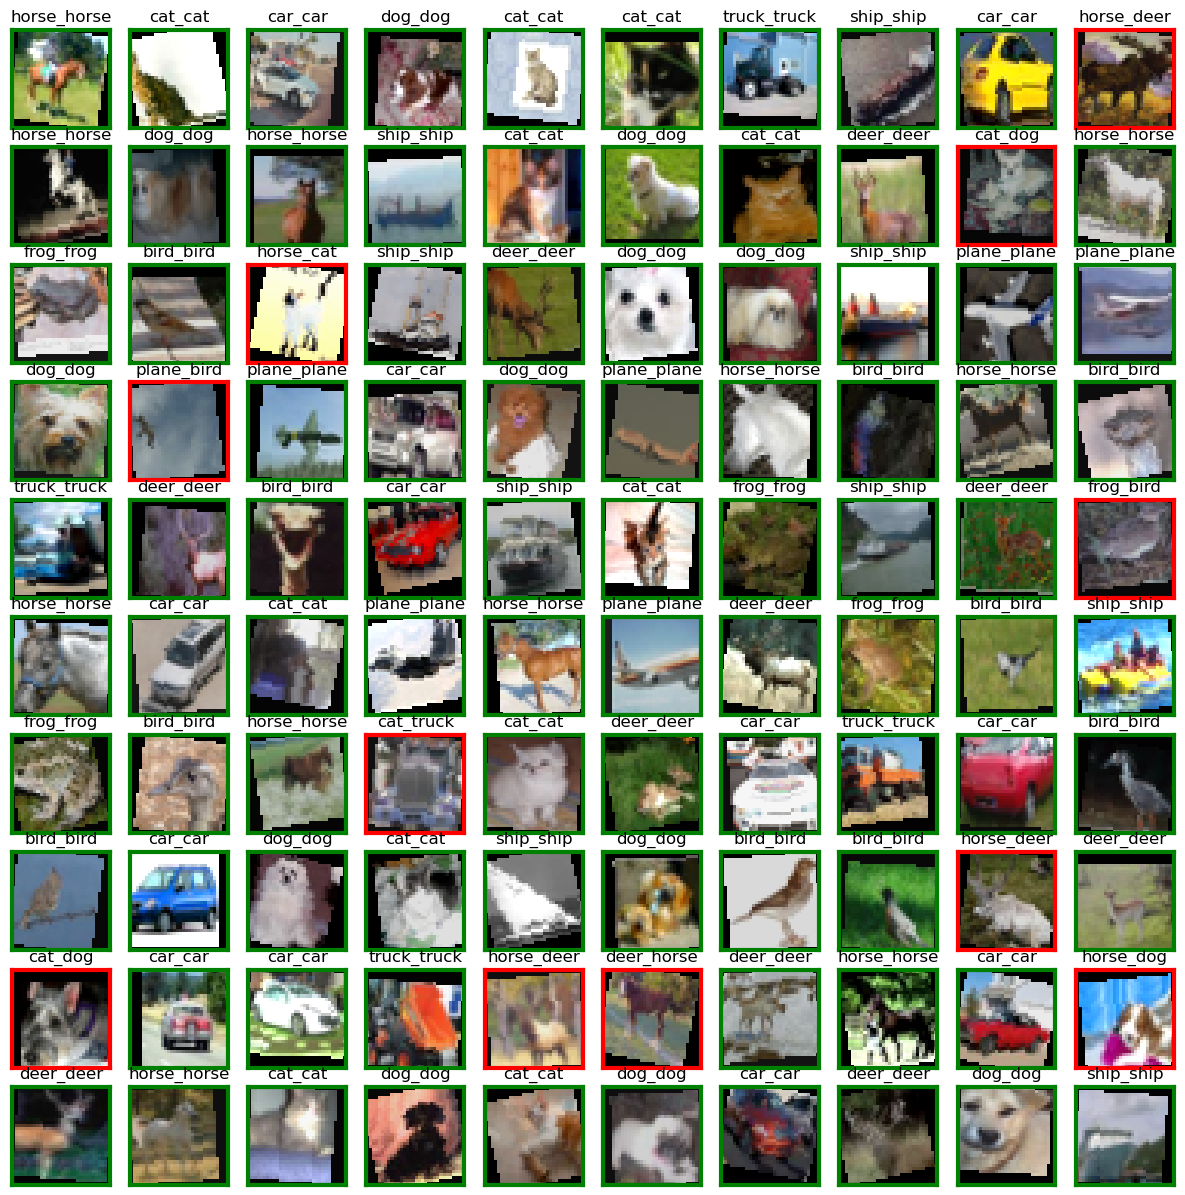

In [7]:
# get train datasets run prediction
train_loader = DataLoader(cifar_data._train_dataset, batch_size=32, shuffle=False)
pred_train_loader = cifar_trainer.predict(cifar_nn, dataloaders = train_loader)
print(f'\n\n\nThe accuracy of the train dataset is {cal_accuracy(train_loader, pred_train_loader)}\n\n\n')
plot_util(train_loader, pred_train_loader)

Predicting DataLoader 0: 100%|██████████| 79/79 [00:00<00:00, 87.41it/s]



The accuracy of the validaiton dataset is 0.89





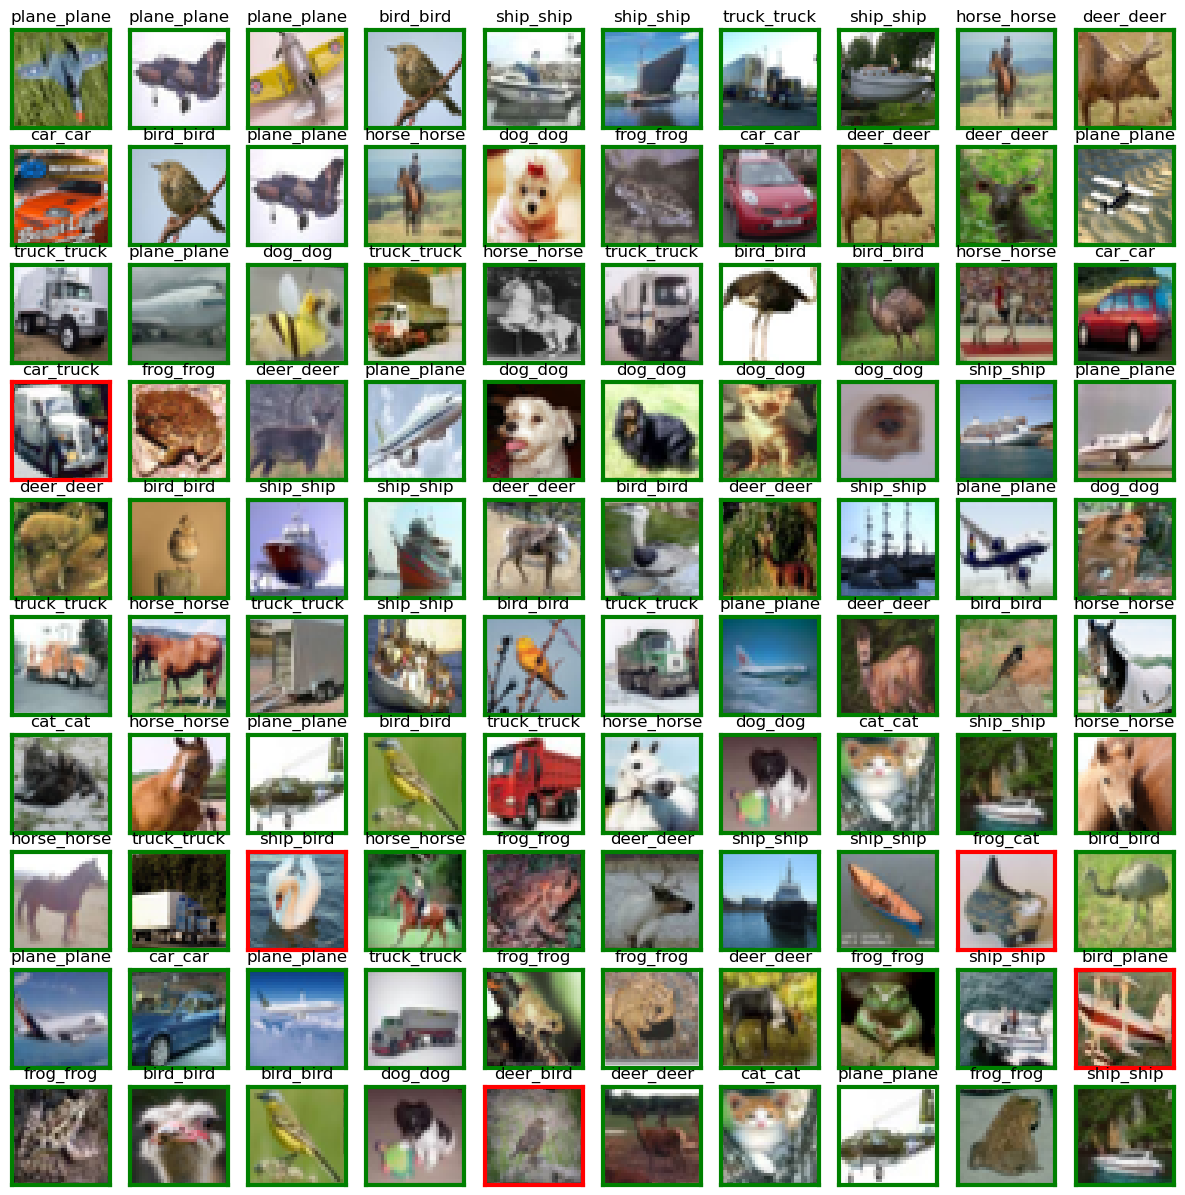

In [8]:
val_loader = DataLoader(cifar_data._val_dataset, batch_size=32, shuffle=False)
pred_val_loader = cifar_trainer.predict(cifar_nn, dataloaders = val_loader)
print(f'\n\n\nThe accuracy of the validaiton dataset is {cal_accuracy(val_loader, pred_val_loader)}\n\n\n')
plot_util(val_loader, pred_val_loader)

Predicting DataLoader 0: 100%|██████████| 313/313 [00:03<00:00, 102.22it/s]



The accuracy of the test dataset is 0.8801





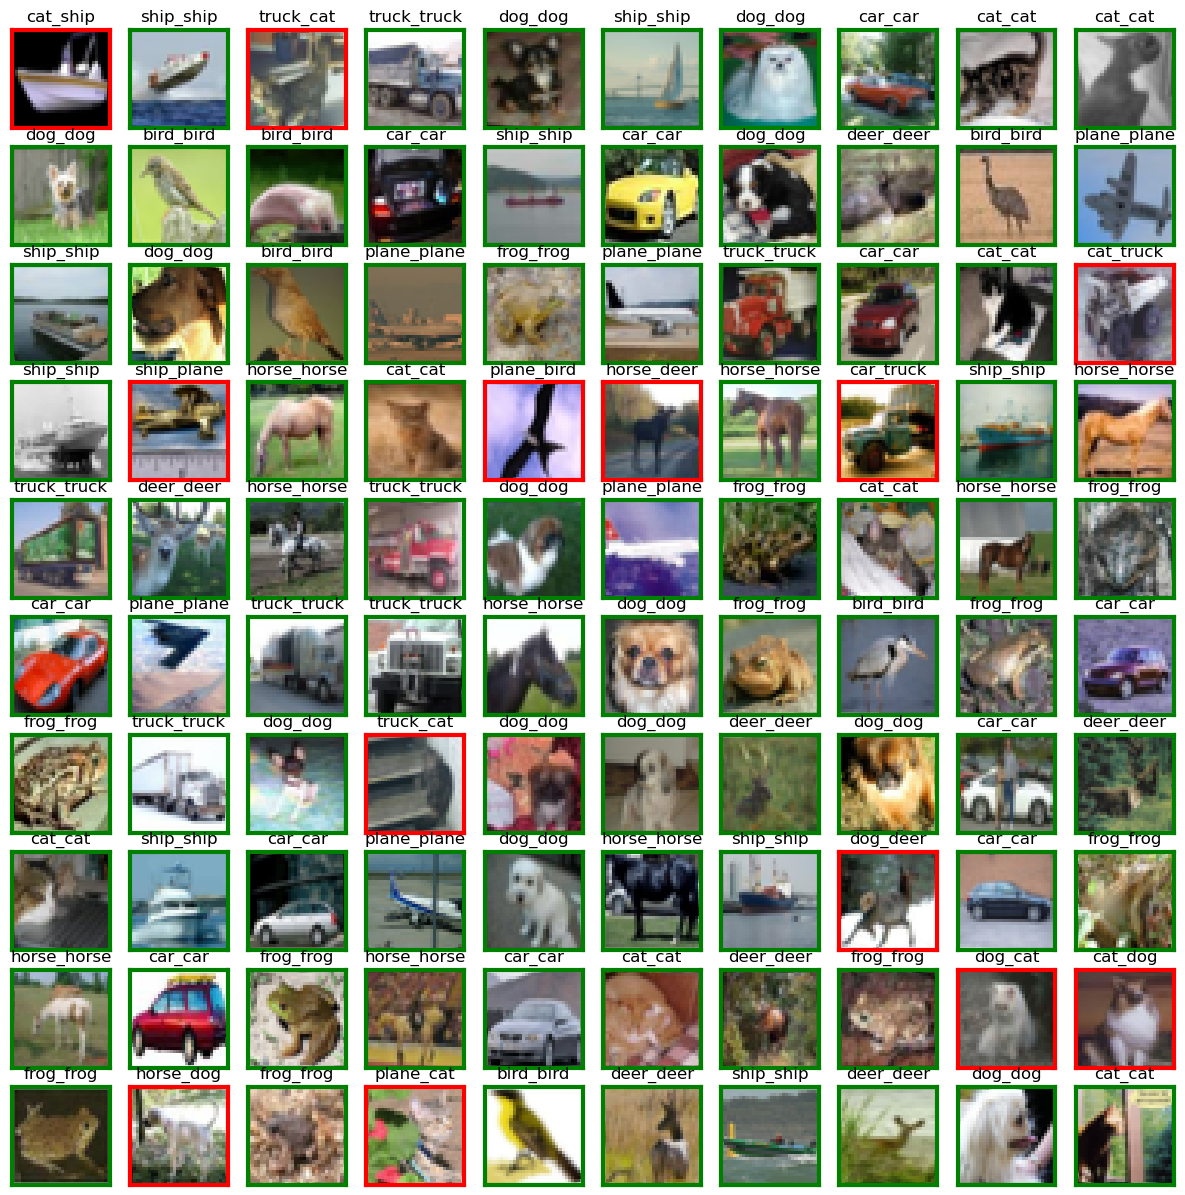

In [9]:
test_loader = DataLoader(cifar_data._test_dataset, batch_size=32, shuffle=False)
pred_test_loader = cifar_trainer.predict(cifar_nn, dataloaders = test_loader)
print(f'\n\n\nThe accuracy of the test dataset is {cal_accuracy(test_loader, pred_test_loader)}\n\n\n')
plot_util(test_loader, pred_test_loader)